In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import os

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("使用设备：", device)

使用设备： cuda


In [ ]:
from pathlib import Path

csv_files=list(Path("/kaggle/input").rglob("*.csv"))

for file in csv_files:
    print(file)



/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv
/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset,DataLoader

torch.manual_seed(42)

device=torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("使用设备: ",device)

使用设备:  cuda


In [ ]:
train_path="/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv"
test_path="/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv"

train_df=pd.read_csv(train_path)
test_df=pd.read_csv(test_path)

print("训练数据形状: ",train_df.shape)
print("测试数据形状: ",test_df.shape)

train_df.head()

训练数据形状:  (60000, 785)
测试数据形状:  (10000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y_train=torch.tensor(
    train_df.iloc[:,0].values,
    dtype=torch.long
)

y_test=torch.tensor(
    test_df.iloc[:,0].values,
    dtype=torch.long
)

X_train=torch.tensor(
    train_df.iloc[:,1:].values,
    dtype=torch.float32
) / 255.0

X_test=torch.tensor(
    test_df.iloc[:,1:].values,
    dtype=torch.float32
) / 255.0

X_train=X_train.reshape(-1,1,28,28)
X_test=X_test.reshape(-1,1,28,28)

print("训练图片: ", X_train.shape)
print("训练标签: ",y_train.shape)
print("测试图片: ",X_test.shape)
print("测试标签: ",y_test.shape)



训练图片:  torch.Size([60000, 1, 28, 28])
训练标签:  torch.Size([60000])
测试图片:  torch.Size([10000, 1, 28, 28])
测试标签:  torch.Size([10000])


In [ ]:
train_dataset=TensorDataset(X_train,y_train)
test_dataset=TensorDataset(X_test,y_test)

train_loader=DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,batch_size=64,
    shuffle=False
)

print("训练批次数量: ",len(train_loader))
print("测试批次数量: ",len(test_loader))

训练批次数量:  938
测试批次数量:  157


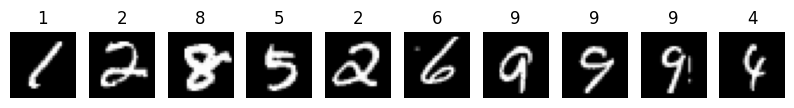

In [ ]:
images,labels=next(iter(train_loader))

plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(images[i].squeeze(),cmap="gray")
    plt.title(labels[i].item())
    plt.axis("off")

plt.show()



In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1=nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )
        
        self.conv2=nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )
        
        self.relu=nn.ReLU()
        self.pool=nn.MaxPool2d(kernel_size=2)

        self.fc=nn.Linear(32*7*7,10)

    def forward(self,x):
        x=self.pool(self.relu(self.conv1(x)))
        x=self.pool(self.relu(self.conv2(x)))

        x=torch.flatten(x,start_dim=1)
        x=self.fc(x)

        return x

In [ ]:
model=SimpleCNN().to(device)

criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)


In [ ]:
num_epochs=3

epoch_losses=[]
batch_losses=[]

for epoch in range(num_epochs):
    model.train()
    
    running_loss=0.0
    
    for images,labels in train_loader:
        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()
        
        predictions=model(images)
        
        loss=criterion(predictions,labels)
        
        loss.backward()
        
        optimizer.step()
        
        running_loss+=loss.item()
        batch_losses.append(loss.item())

    average_loss=running_loss/len(train_loader)
    epoch_losses.append(average_loss)
    
    print(
        f"Epoch [{epoch+1}/{num_epochs}], S"
        f"平均 Loss: {average_loss:.4f}"
        
    )
        

Epoch [1/3], S平均 Loss: 0.2394
Epoch [2/3], S平均 Loss: 0.0685
Epoch [3/3], S平均 Loss: 0.0518


In [ ]:
model.eval()

correct=0
total=0
test_loss=0.0

with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)

        predictions=model(images)
        loss=criterion(predictions,labels)

        test_loss+=loss.item()

        predicted_labels=predictions.argmax(dim=1)
        
        total+=labels.size(0)
        correct+=(predicted_labels==labels).sum().item()

average_test_loss=test_loss/len(test_loader)
accuracy=100*correct/total

print(f"测试 Loss:{average_test_loss:.4f}")
print(f"测试准确率 :{accuracy:.2f}%")


测试 Loss:0.0458
测试准确率 :98.46%


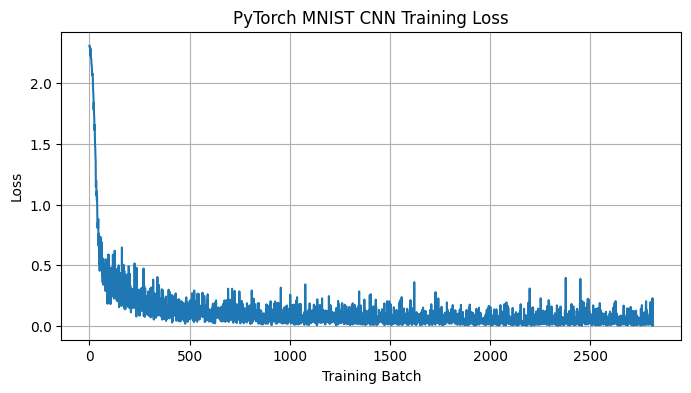

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(batch_losses)
plt.xlabel("Training Batch")
plt.ylabel("Loss")
plt.title("PyTorch MNIST CNN Training Loss")
plt.grid(True)

plt.show()

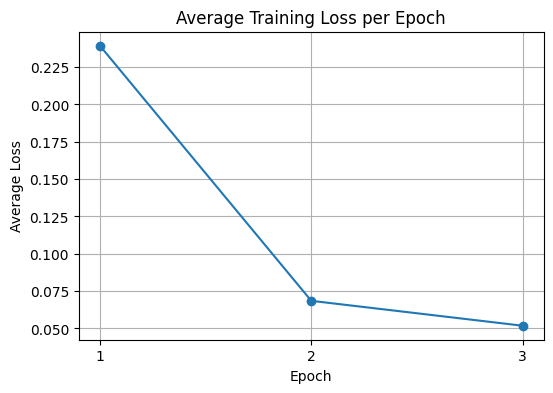

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(
    range(1,num_epochs+1),
    epoch_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Average Training Loss per Epoch")
plt.xticks(range(1,num_epochs+1))
plt.grid(True)

plt.show()

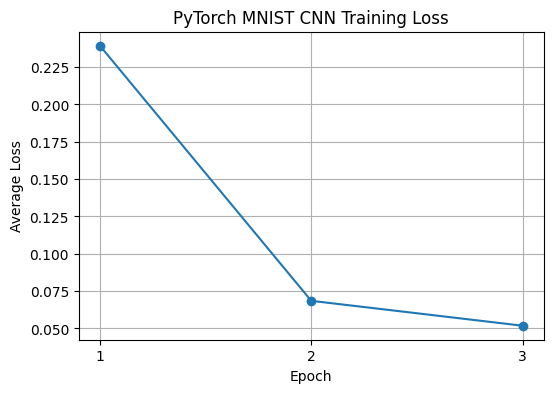

保存完成：
['loss_curve.png', 'mnist_cnn.pth', 'training_history.csv']


In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch

results_dir = "/kaggle/working/results"
os.makedirs(results_dir, exist_ok=True)

# 保存模型参数
torch.save(
    model.state_dict(),
    f"{results_dir}/mnist_cnn.pth"
)

# 保存每轮训练Loss
history_df = pd.DataFrame({
    "epoch": range(1, len(epoch_losses) + 1),
    "train_loss": epoch_losses
})

history_df.to_csv(
    f"{results_dir}/training_history.csv",
    index=False
)

# 保存Loss曲线
plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(epoch_losses) + 1),
    epoch_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("PyTorch MNIST CNN Training Loss")
plt.xticks(range(1, len(epoch_losses) + 1))
plt.grid(True)

plt.savefig(
    f"{results_dir}/loss_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("保存完成：")
print(os.listdir(results_dir))

In [ ]:
summary = {
    "epochs": num_epochs,
    "batch_size": 64,
    "learning_rate": 0.001,
    "test_loss": float(average_test_loss),
    "test_accuracy_percent": float(accuracy)
}

with open(
    "/kaggle/working/results/test_results.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(summary, file, indent=2)

print(summary)

{'epochs': 3, 'batch_size': 64, 'learning_rate': 0.001, 'test_loss': 0.045751807736277364, 'test_accuracy_percent': 98.46}
